# 1. Criando seno de amplitude e frequência variável (linearmente)

Neste caso, a amplitude e a frequência variam de forma linear com o tempo, conforme descrito pelas equações abaixo:

$$
A_d(t) = b_d + c_d \cdot t, \quad
A_e(t) = b_e + c_e \cdot t
$$

$$
f_d(t) = f_{0d} + f_{1d} \cdot t, \quad
f_e(t) = f_{0e} + f_{1e} \cdot t
$$

A frequência angular é dada por:

$$
\omega_d(t) = 2\pi f_d(t), \quad
\omega_e(t) = 2\pi f_e(t)
$$

A fase é calculada como a integral da frequência angular:

$$
\phi_d(t) = \int_0^t \omega_d(\tau) \, d\tau, \quad
\phi_e(t) = \int_0^t \omega_e(\tau) \, d\tau
$$

Por fim, os sinais senoides resultantes são definidos por:

$$
\varphi_d(t) = A_d(t) \cdot \sin(\phi_d(t)), \quad
\varphi_e(t) = A_e(t) \cdot \sin(\phi_e(t))
$$


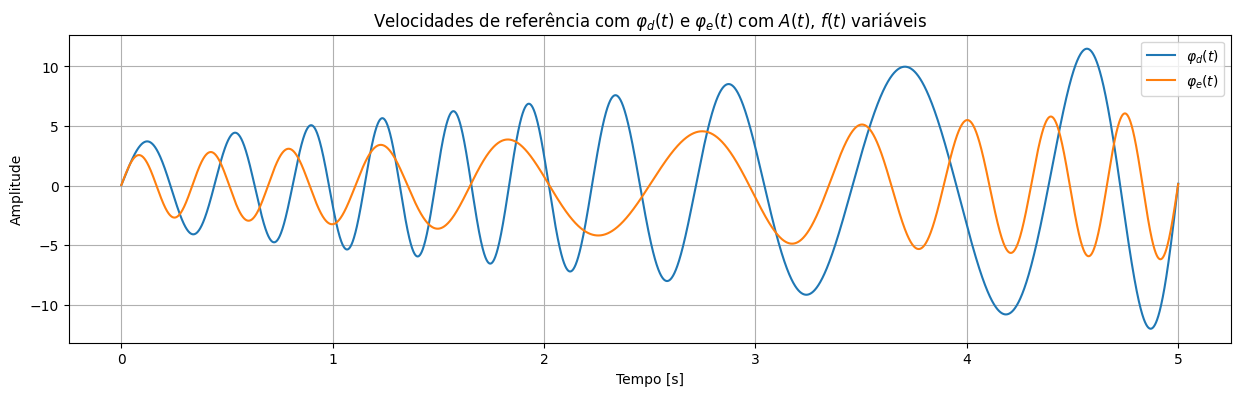

In [26]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 5, 5000)  # 5 segundos

# Amplitude e frequência variáveis
A_d = (1 + 0.5 * t) * 3.5
A_e = (1 + 0.3 * t) * 2.5
f_d = 2 + np.sin(2 * np.pi * 0.2 * t)
f_e = 2 + np.cos(2 * np.pi * 0.2 * t)

# Fases integradas
omega_d = 2 * np.pi * f_d
omega_e = 2 * np.pi * f_e

phi_d = A_d * np.sin(np.cumsum(omega_d) * (t[1] - t[0]))
phi_e = A_e * np.sin(np.cumsum(omega_e) * (t[1] - t[0]))

# Plot
plt.figure(figsize=(15,4))
plt.plot(t, phi_d, label=r'$\varphi_d(t)$')
plt.plot(t, phi_e, label=r'$\varphi_e(t)$')
plt.legend()
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.title(r'Velocidades de referência com $\varphi_d(t)$ e $\varphi_e(t)$ com $A(t)$, $f(t)$ variáveis')
plt.grid(True)
plt.legend()
plt.show()


# 2. Resolvendo o sistema dinâmico usando método de Euler

$$ \begin{bmatrix}
\dot{x}_a \\
\dot{y}_a \\
\dot{\theta}
\end{bmatrix}
= 

\frac{R}{2} \cdot
\begin{bmatrix}
\cos \theta & \cos \theta \\
\sin \theta & \sin \theta \\
\frac{1}{L} & -\frac{1}{L}
\end{bmatrix}

\cdot

\begin{bmatrix}
\varphi_D \\
\varphi_E
\end{bmatrix}
$$

In [27]:

# Constantes do sistema
R = 0.034  # raio da roda [m]
L = 0.147/2  # distância entre rodas [m]

# Estados: [x, y, theta]
x = np.zeros_like(t)
y = np.zeros_like(t)
theta = np.zeros_like(t)

# Integração via método de Euler
for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    th = theta[i-1]

    v = (R / 2) * (phi_d[i-1] + phi_e[i-1])
    w = (R / (2 * L)) * (phi_d[i-1] - phi_e[i-1])

    x[i] = x[i-1] + v * np.cos(th) * dt
    y[i] = y[i-1] + v * np.sin(th) * dt
    theta[i] = theta[i-1] + w * dt


# 3. Plotando a trajetória do robô

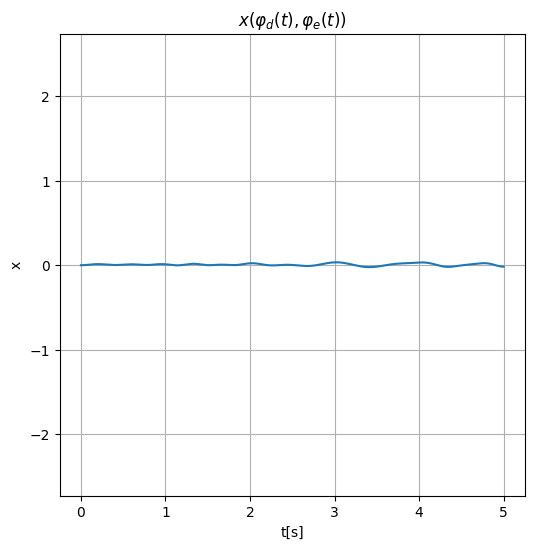

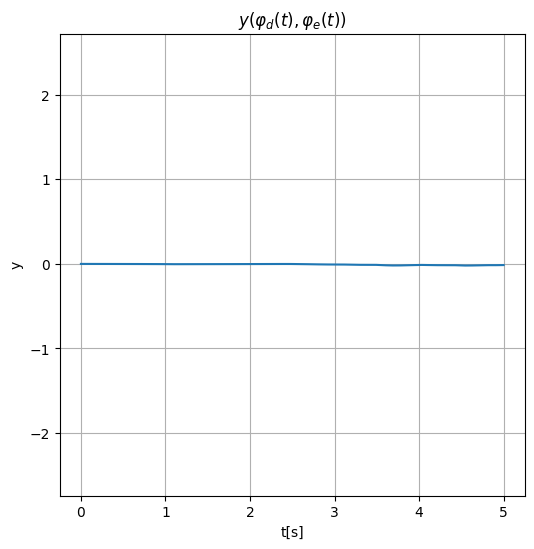

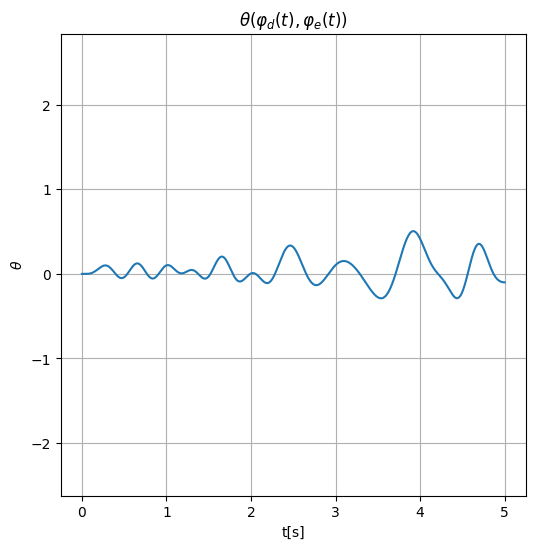

In [28]:

plt.figure(figsize=(6,6))
plt.plot(t, x)
plt.xlabel('t[s]')
plt.ylabel('x')
plt.title(r'$x(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.plot(t, y)
plt.xlabel('t[s]')
plt.ylabel('y')
plt.title(r'$y(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()


plt.figure(figsize=(6,6))
plt.plot(t, theta)
plt.xlabel('t[s]')
plt.ylabel(r'$\theta$')
plt.title(r'$\theta(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()


In [29]:
import pandas as pd

# Criar DataFrame com os dados simulados
df = pd.DataFrame({
    'tempo_s': t,
    'phi_d': phi_d,
    'phi_e': phi_e,
    'x_m': x,
    'y_m': y,
    'theta_rad': theta
})

# Exibir as primeiras linhas do DataFrame
display(df.head())

# Salvar em CSV
df.to_csv('LinearData.csv', index=False)

,tempo_s,phi_d,phi_e,x_m,y_m,theta_rad
0,0.000000,0.043990,0.047131,0.000000,0.000000e+00,0.000000e+00
1,0.001000,0.088045,0.094273,0.000002,0.000000e+00,-7.265396e-07
2,0.002000,0.132157,0.141409,0.000005,-2.252281e-12,-2.167316e-06
3,0.003001,0.176320,0.188524,0.000009,-1.233367e-11,-4.307749e-06
4,0.004001,0.220527,0.235600,0.000016,-3.905718e-11,-7.130991e-06
